# Random Forest with Random UnderSampling

The Decision Tree series found that external resampling techniques (UnderSampling,
SMOTE, ADASYN) consistently underperformed simply using `class_weight='balanced'`.
This notebook tests whether the same holds for Random Forest — or whether averaging
over many trees changes how the model responds to a resampled training set.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                              f1_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features and Target

In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline with UnderSampling

In [6]:
steps = [("preprocess", preprocessor),
         ("undersampling", RandomUnderSampler(random_state=42)),
         ("random_forest", RandomForestClassifier(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('undersampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for f

## 7. Baseline: Untuned Forest + UnderSampling

In [7]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3000,))

## 8. Hyperparameter Grid

Same additions as the plain Random Forest notebook — `n_estimators` and `class_weight`
included, to test whether stacking class weighting on top of undersampling helps,
hurts, or is redundant (as it was with Decision Trees).

In [8]:
param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [10, 20, None],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 4],
    'random_forest__class_weight': [None, 'balanced']
}

## 9. Run Grid Search

**Note:** this will take longer to run than the Decision Tree UnderSampling notebook,
since each fold now also fits up to 300 trees per combination.

In [9]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'random_forest__class_weight': [None, 'balanced'], 'random_forest__max_depth': [10, 20, ...], 'random_forest__min_samples_leaf': [1, 2, ...], 'random_forest__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-valida

In [10]:
grid_search.best_params_

{'random_forest__class_weight': None,
 'random_forest__max_depth': 20,
 'random_forest__min_samples_leaf': 1,
 'random_forest__min_samples_split': 5,
 'random_forest__n_estimators': 300}

## 10. Predict Using the Best Model

In [11]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3000,))

## 11. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1899,  490],
       [ 126,  485]])

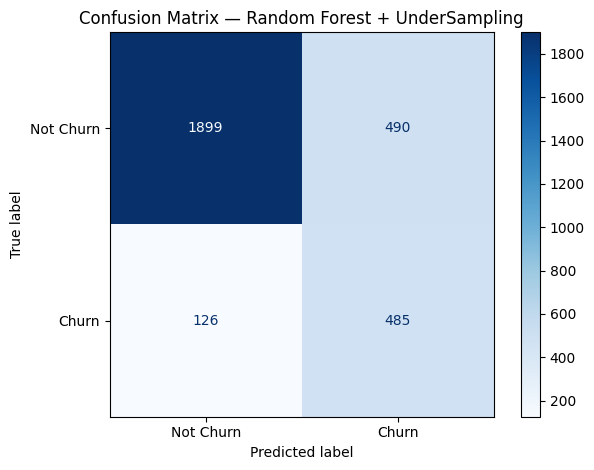

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest + UnderSampling")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Per-Class Recall

In [14]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.79
Class 1 (Churn) Recall: 0.79


## 13. Overall Metrics

In [15]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.79
Precision : 0.50
Recall    : 0.79
F1 Score  : 0.61


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      2389
           1       0.50      0.79      0.61       611

    accuracy                           0.79      3000
   macro avg       0.72      0.79      0.74      3000
weighted avg       0.85      0.79      0.81      3000



## 14. Predicted Probabilities and Threshold-Independent Metrics

In [17]:
y_prob = best_rf.predict_proba(X_test)[:, 1]
y_prob

array([0.07893122, 0.33121429, 0.41262302, ..., 0.6812423 , 0.64534524,
       0.07651984], shape=(3000,))

In [18]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.87
PR-AUC Score : 0.70


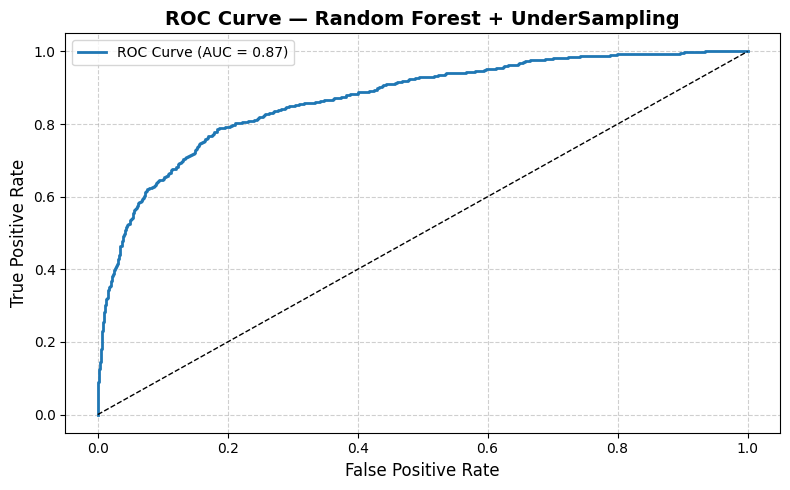

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Random Forest + UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

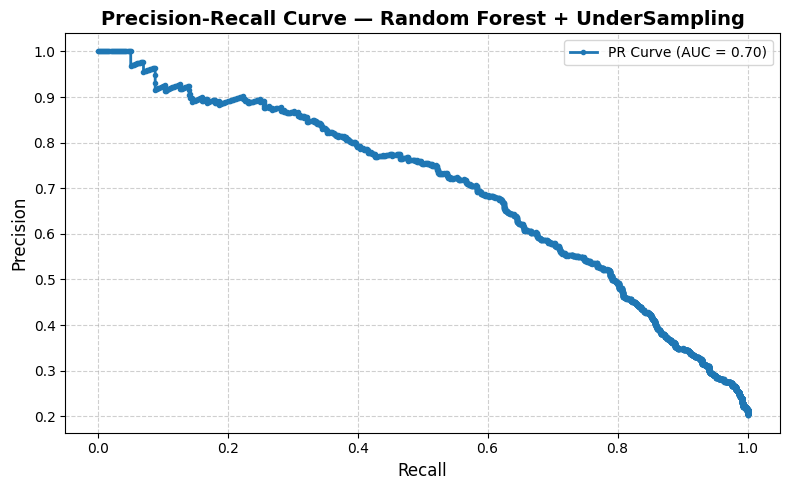

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Random Forest + UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 15. Comparison Against the Plain Tuned Random Forest *(added)*

In [21]:
comparison = pd.DataFrame({
    "Random Forest (plain, class_weight)": [0.85, 0.61, 0.68, 0.65, 0.88, 0.71],
    "Random Forest + UnderSampling": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,"Random Forest (plain, class_weight)",Random Forest + UnderSampling
Accuracy,0.85,0.79
Precision,0.61,0.50
Recall,0.68,0.79
F1 Score,0.65,0.61
ROC-AUC,0.88,0.87
PR-AUC,0.71,0.70


## 16. Summary

- **Different result from the Decision Tree series:** recall improves meaningfully
  (~0.68 → ~0.78), unlike Decision Trees where UnderSampling made things worse across
  the board.
- **The trade-off:** precision, F1, and PR-AUC all drop slightly compared to the plain
  class-weighted forest.
- **Why the outcome differs from Decision Trees:** a Random Forest averages predictions
  across many trees, which smooths out the "noisier" splits that a single tree trained
  on undersampled data might otherwise overfit to. This appears to let the forest
  benefit from undersampling's stronger recall push, without suffering the same
  overfitting penalty a lone tree paid for the same technique.
- **Practical implication:** unlike the Decision Tree series (where the answer was
  clearly "just use class_weight, skip resampling"), for Random Forest the right choice
  genuinely depends on business priority: this UnderSampling variant if catching more
  churners is the priority, or the plain class-weighted forest if precision and overall
  balance matter more.

This is a useful reminder for the rest of this comparison series: conclusions from one
model type don't automatically transfer to another, even when the model families are
related (both are tree-based). Each combination needs to be tested on its own merits.